<a href="https://colab.research.google.com/github/mercadocesar995/analisis_NovaReatil-/blob/main/Analisis_Novaretail%2B2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 # Importar librerías



### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos
El dataset contiene las siguientes columnas:
- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 0.0 al 5.0.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
print(df.head()) # mostrar las primeras 5 filas


  id_cliente  edad  nivel_ingreso  visitas_mes  compras_mes  \
0  CL-100000  44.0       28565.77            9            1   
1  CL-100001  36.0       29673.44           11            3   
2  CL-100002  46.0       30642.95            9            0   
3  CL-100003  56.0       39468.61            8            0   
4  CL-100004  35.0       22527.83            9            2   

   gasto_publicidad_dirigida  satisfaccion  miembro_premium  abandono  \
0                      31.36           3.9                0         0   
1                      24.66           3.7                0         0   
2                       0.00           2.9                0         0   
3                       6.81           3.1                0         0   
4                      26.49           2.3                0         0   

  tipo_dispositivo region  ingreso_anual  
0            móvil  norte          23.22  
1           tablet    sur          93.47  
2            móvil   este           0.00  
3         

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza


💡
Después de una primera revisión de la base de Nova Retail, se observa que contiene 15.000 clientes y 12 variables. No se encontraron valores faltantes, por lo que todos los registros pueden utilizarse en el análisis.

También se revisaron los tipos de datos para determinar si son adecuados para cada variable. Las columna edad está representada como valor decimal(float64), pero se recomienda convertirla a número entero (int64). La edad se expresa en años completos, lo que facilita su interpretación y el análisis por edad.
Las columnas miembro_premium y abandono están como números enteros (int64), pero pueden convertirse a valores booleanos (True/False), ya que únicamente indican si el cliente pertenece al programa premium o si abandonó la plataforma.

Las columnas id_cliente, tipo_dispositivo y region están como texto (object) y deben mantenerse así, id_cliente funciona como identificador y no requiere operaciones matemáticas, mientras que las otras dos contienen categorías que serán útiles para comparar grupos de clientes.
Las variables de satisfaccion, nivel_ingreso, gasto_publicidad_dirigida e ingreso_anual deben mantenerse como float64, ya que representan valores monetarios o calificacion del cliente donde pueden contener decimales. Finalmente, visitas_mes y compras_mes están correctamente como int64, porque representan cantidades enteras de visitas y compras.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`: float64 Representa la edad del cliente en años. Al ser un número entero, facilita comparaciones y análisis por edad.

- `nivel_ingreso`: float64	Representa el ingreso estimado del cliente y puede contener valores decimales.

- `visitas_mes`: int64	Cuenta la cantidad de visitas realizadas durante el mes, por lo que son valores enteros.

- `compras_mes`:	int64	Representa el número de compras realizadas. No existen fracciones de una compra.

- `gasto_publicidad_dirigida`:	float64	Es un valor monetario que puede incluir decimales.

- `satisfaccion`:	float64	Representa una calificación que puede tomar valores decimales entre 0.0 y 5.0, permitiendo reflejar con mayor precisión el nivel de satisfacción del cliente.

- `ingreso_anual`:	float64	Representa el ingreso generado por cada cliente y puede contener valores decimales.

La mayoría de estas variables presentan tipos de datos adecuados.  



**Variables binarias**  
Las siguientes columnas representan variables binarias:

- `miembro_premium`: Es una variable que esta categorizada por la membresia de los clientes donde, (1 = cliente premium, 0 = cliente no premium).
  
- `abandono`: Es una variable que esta categorizada por el abandono de la plataforma donde: (1 = cliente que abandonó la plataforma, 0 = cliente que permanece).

Ambas columnas están codificadas como 0 y 1, se recomienda transformar de int64 a booleanos (True/False) ya que estas variables no representan cantidades, sino condiciones con solo dos posibilidades.


**Variables categóricas**  
Se identifican las siguientes columnas categóricas:

- `id_cliente`: Es un identifcicador su función es identificar de manera única a cada cliente y no representar una característica numérica.
  
- `tipo_dispositivo`: indica si el cliente utiliza móvil, escritorio o tablet. Permite identificar qué dispositivos son más utilizados.

  
- `region`: clasifica a los clientes en norte, sur, oeste o este. Permite conocer cómo se distribuyen los clientes geográficamente.

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
# Convertir edad a entero
df['edad'] = df['edad'].astype('int64')
# Convertir variables binarias a booleanas
df['miembro_premium'] = df['miembro_premium'].astype(bool)
df['abandono'] = df['abandono'].astype(bool)

In [ ]:
# verificar cambios
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  bool   
 8   abandono                   15000 non-null  bool   
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: bool(2), float64(4), int64(3), object(3)
memory usage: 1.2+ MB


id_cliente                    object
edad                           int64
nivel_ingreso                float64
visitas_mes                    int64
compras_mes                    int64
gasto_publicidad_dirigida    float64
satisfaccion                 float64
miembro_premium                 bool
abandono                        bool
tipo_dispositivo              object
region                        object
ingreso_anual                float64
dtype: object

#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas = df.select_dtypes(include='number').columns

# Mostrar las variables numéricas
print("Variables numéricas:")
print(columnas_numericas)

# Resumen estadístico
df[columnas_numericas].describe()

Variables numéricas:
Index(['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
       'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual'],
      dtype='object')


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**:
## Diagnóstico inicial de variables numéricas

- `Edad`: Los clientes tienen entre 18 y 75 años, con una edad promedio de 38,3 años y una mediana de 38 años. La cercanía entre ambos valores sugiere una distribución relativamente equilibrada de las edades. Esta variable permitirá evaluar posteriormente si existen diferencias en el comportamiento de los clientes según su edad.
- `Nivel de ingreso`: Presenta valores entre 8.000 y 74.790,84, con un promedio de 30.01 y una mediana de 30.02. La distribución se encuentra bastante centrada alrededor de los 30.000. Es importante diferenciar esta variable de ingreso_anual, ya que ambas presentan escalas y magnitudes muy diferentes; por ello, será necesario revisar su definición y relación antes de establecer interpretaciones.
- `Visitas por mes`:Los clientes registran entre 1 y 25 visitas mensuales, con un promedio y una mediana cercanos a 10 visitas. El 50% central de los clientes se concentra entre 8 y 12 visitas al mes, lo que indica una distribución relativamente concentrada alrededor de ese nivel de interacción.
- `Compras por mes`: La frecuencia de compra se concentra en niveles bajos: el 25% de los clientes no realiza compras y la mitad de la base registra como máximo 1 compra mensual. Aunque la mayoría de los clientes compra poco, algunos alcanzan hasta 8 compras al mes, lo que evidencia la existencia de un grupo reducido de clientes con una actividad de compra considerablemente mayor.
- `Gasto en publicidad dirigida`:El gasto asignado por cliente varía entre 0 y 75,51, con un promedio de 20,15 y una mediana de 19,73. El 50% central de los clientes se encuentra entre 12,31 y 27,29. Estos valores permiten caracterizar la distribución de la inversión publicitaria y posteriormente analizar su relación con el comportamiento de los clientes.
- `Satisfacción`: Las calificaciones observadas se encuentran entre 1 y 5, incluyendo valores decimales. El promedio y la mediana son de 3,60, con una desviación estándar de 0,69, lo que indica una dispersión relativamente baja de las respuestas alrededor del promedio. Esta variable permitirá evaluar posteriormente si existe alguna relación entre la satisfacción y las demás métricas analizadas.
- `Ingreso anual`: Presenta valores entre 0 y 244,69, con un promedio de 36,59 y una mediana de 30,71. El 25% de los registros presenta un valor de 0, mientras que el valor máximo alcanza 244,69, lo que evidencia una distribución con sesgo positivo y una dispersión considerable. Por su comportamiento y por ser una de las variables centrales del análisis, será necesario revisar con mayor detalle la concentración de ceros y los valores elevados antes de realizar interpretaciones o modelos predictivos.

#### Explorar variables binarias

In [ ]:
print("Miembro premium:")
print(df['miembro_premium'].unique())

print("\nAbandono:")
print(df['abandono'].unique()) # Verificar que cada columna tenga únicamente dos valores posibles


Miembro premium:
[False  True]

Abandono:
[False  True]


✍️ **Comentario**:
## Diagnóstico inicial de variables binarias

- `miembro_premium`: Permite identificar qué proporción de los clientes cuenta con una suscripción premium y cuál no. Esta variable es relevante para determinar si pertenecer al programa premium está relacionado con un mayor ingreso anual generado.
- `abandono`: Permite identificar qué proporción de clientes continúa utilizando la plataforma y cuál la ha abandonado. Es importante analizarla porque puede mostrar si la pérdida de clientes está relacionada con los ingresos generados y, especialmente, si Nova Retail está perdiendo clientes de alto valor.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
# Valores únicos de tipo de dispositivo
print("Tipo de dispositivo:")
print(df['tipo_dispositivo'].unique())

# Valores únicos de región
print("\nRegión:")
print(df['region'].unique())

Tipo de dispositivo:
['móvil' 'tablet' 'escritorio']

Región:
['norte' 'sur' 'este' 'oeste']


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("Distribución por dispositivo:")
print(df['tipo_dispositivo'].value_counts())

# Distribución por región
print("\nDistribución por región:")
print(df['region'].value_counts())

Distribución por dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución por región:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**:
## Diagnóstico inicial de variables categóricas

- `Tipo_dispositivo`: La mayoría de los clientes utiliza móvil, con 9.818 registros, seguido de escritorio con 3.720 y tablet con 1.462. Esto muestra una clara preferencia por el uso de dispositivos móviles podria ser un foco de revision clave.
- `Región`: La distribución es más equilibrada. La región norte concentra la mayor cantidad de clientes con 4.395, seguida de oeste con 3.810, sur con 3.726 y este con 3.069. Aunque existen diferencias entre regiones, ninguna concentra por sí sola una proporción excesivamente alta de clientes.

### Supuestos
- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

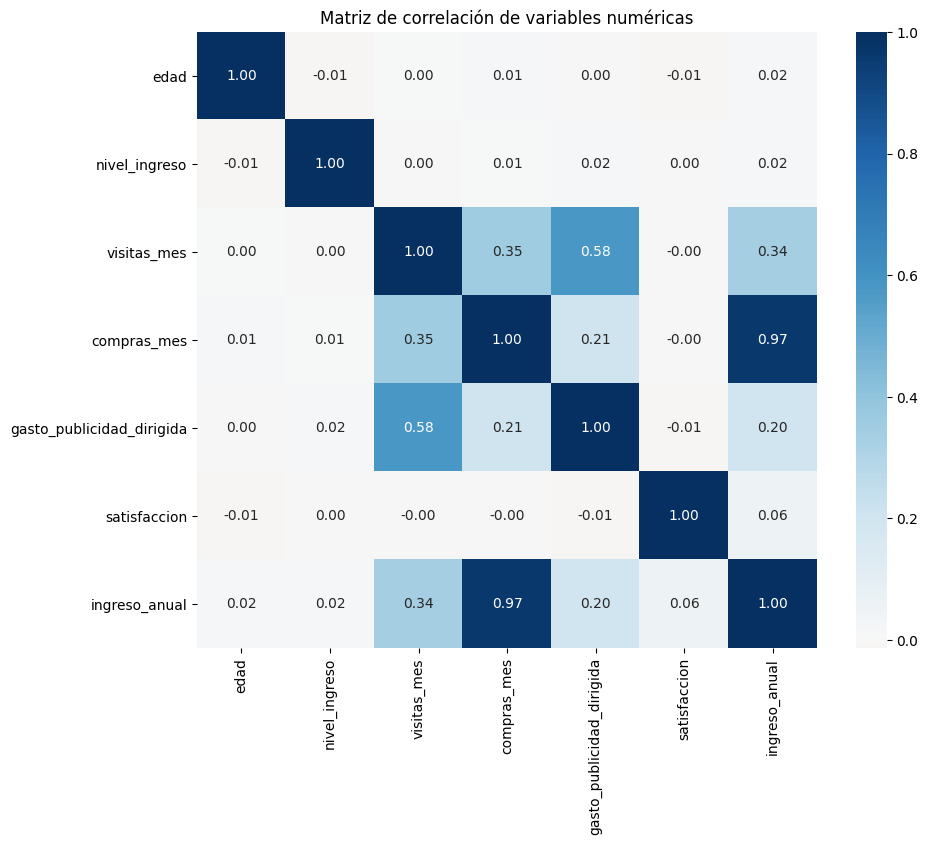

In [ ]:
# Seleccionar las variables numéricas
variables_numericas = df.select_dtypes(include='number')

# Crear la matriz de correlación
matriz_corr = variables_numericas.corr()

# Mostrar la matriz
matriz_corr

# Visualizar la matriz de correlación para identificar relaciones

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='RdBu',
    center=0,
    fmt='.2f')

plt.title('Matriz de correlación de variables numéricas')
plt.show()

✍️ **Comentario**:

### Observaciones generales (Heatmap)  
El análisis de la matriz de correlación permite identificar diferentes niveles de asociación entre las variables del conjunto de datos. El resultado que requiere mayor atención es la relación entre compras_mes e ingreso_anual, con una correlación de 0,97, que representa una asociación lineal positiva muy alta. Por su magnitud, esta relación constituye un foco prioritario para profundizar en el análisis, especialmente antes de utilizarla como base para conclusiones de negocio.

También se observan asociaciones positivas de menor intensidad, como la existente entre visitas_mes y gasto_publicidad_dirigida (0,58), así como entre visitas_mes y compras_mes (0,35) y entre visitas_mes e ingreso_anual (0,34).
Estas relaciones muestran patrones que pueden ser relevantes, pero no permiten por sí mismas establecer causalidad ni determinar que una variable sea responsable del comportamiento de otra.

Por otra parte, variables como edad y satisfaccion presentan correlaciones cercanas a cero con las principales métricas analizadas, lo que indica una baja asociación lineal dentro de este conjunto de datos.

### Observaciones respecto a `ingreso_anual`  
Dentro de la matriz analizada, ingreso_anual destaca por presentar relaciones positivas con las demás variables, aunque con diferentes niveles de intensidad. Las correlaciones con edad, nivel_ingreso y satisfaccion presentan una magnitud baja a moderada, por lo que, en esta primera revisión, no evidencian una relación lineal particularmente fuerte.

Por otro lado, gasto_publicidad_dirigida y visitas_mes muestran correlaciones positivas de mayor magnitud, con valores de 0,20 y 0,34, respectivamente. Si bien estas asociaciones son más evidentes, todavía no son suficientes para establecer una relación determinante entre las variables.

La relación que requiere mayor atención es la observada entre compras_mes e ingreso_anual, con un coeficiente de 0,97, muy próximo a 1. Esta magnitud indica una asociación lineal positiva extremadamente alta y constituye un foco prioritario para la siguiente etapa del análisis.

Este resultado debe interpretarse como una señal para continuar la investigación y no como evidencia de causalidad.



### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico:

  - Describe brevemente qué patrones o tendencias observas:
El gráfico muestra una relación muy fuerte entre el ingreso anual de los clientes y la cantidad de compras que realizan al mes, en general a medida que aumenta el ingreso anual, también aumenta el número de compras mensuales. Esto coincide con la correlación de 0,97 encontrada inicialmente.
También se observa que la mayoría de los clientes realiza entre 2 y 5 compras al mes, mientras que hay pocos clientes en los niveles más altos de compras.

Por la fuerza de esta relación, se recomienda revisar con mayor detalle cómo se construyeron estas variables y si existen otros factores que puedan estar influyendo en el resultado, antes de utilizarlo para tomar decisiones.

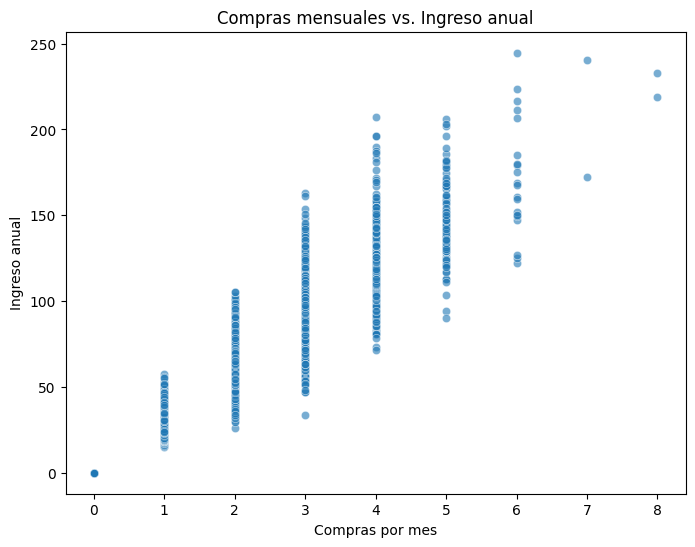

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual',
    alpha=0.6
)

plt.title('Compras mensuales vs. Ingreso anual')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual')
plt.show()

### Scatterplot para pares clave

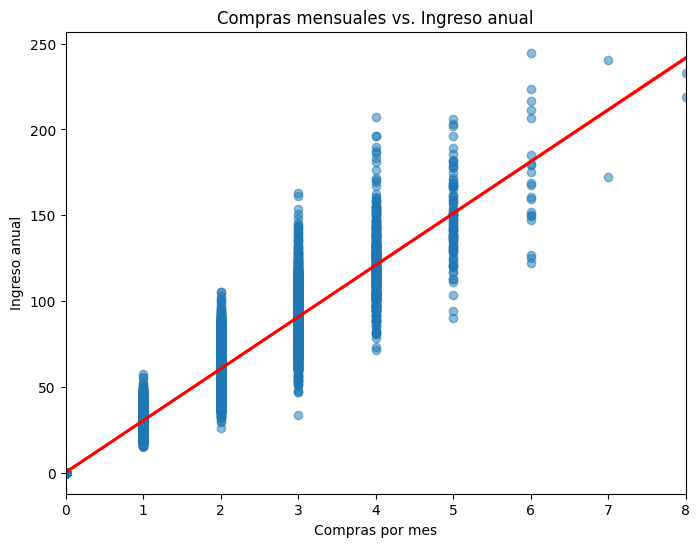

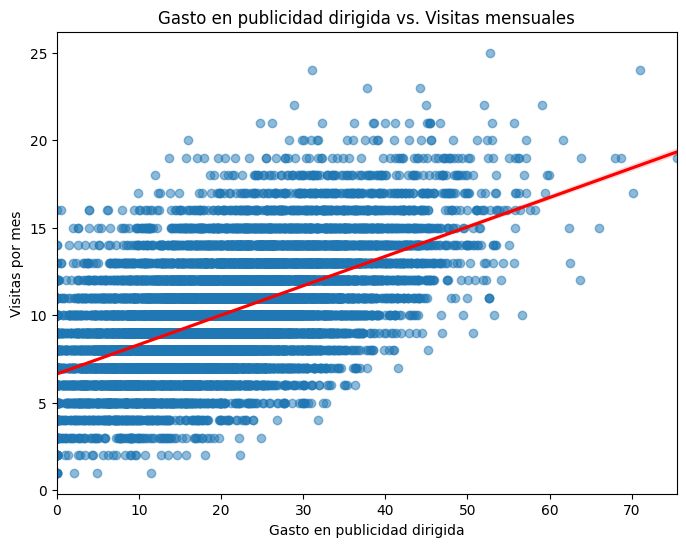

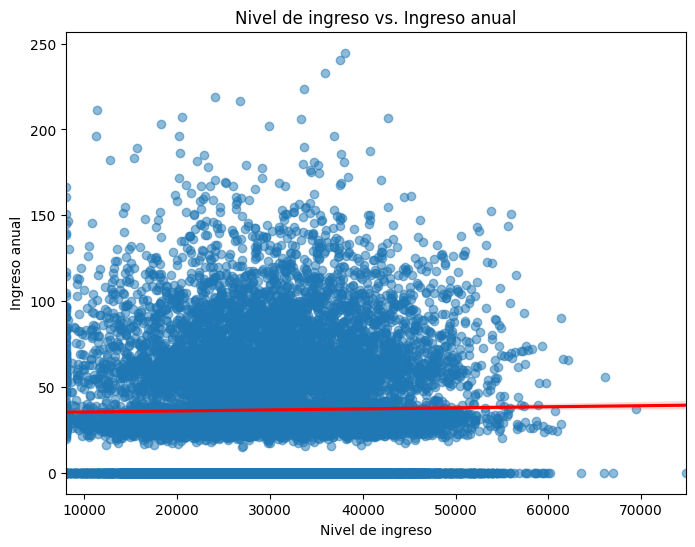

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title('Compras mensuales vs. Ingreso anual')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual')
plt.show()

plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='gasto_publicidad_dirigida',
    y='visitas_mes',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title('Gasto en publicidad dirigida vs. Visitas mensuales')
plt.xlabel('Gasto en publicidad dirigida')
plt.ylabel('Visitas por mes')
plt.show()

plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='nivel_ingreso',
    y='ingreso_anual',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title('Nivel de ingreso vs. Ingreso anual')
plt.xlabel('Nivel de ingreso')
plt.ylabel('Ingreso anual')
plt.show()

✍️ **Comentario**:


## Observaciones iniciales (Scatterplot)

**`compras_mes` vs. `ingreso_anual`**

- Se observa una relación positiva muy fuerte, respaldada por una correlación de 0,97. La dispersión es baja, ya que los puntos se mantienen relativamente cerca de la tendencia. Aunque se identifican algunos puntos alejados, no se observa una cantidad importante de valores atípicos. Debido a la magnitud de la correlación, existe una posible colinealidad entre estas variables si ambas se utilizaran conjuntamente como variables explicativas en un modelo, ya que podrían aportar información redundante


**`gasto_publicidad_dirigida` vs. `visitas_mes`**
- Se observa una relación positiva moderada, con una correlación de 0,58. La dispersión es media-alta, ya que para niveles similares de gasto publicitario se encuentran usuarios con cantidades de visitas diferentes. Esto indica que, aunque existe una tendencia a que un mayor gasto se relacione con más visitas, la relación no es tan consistente como en el caso anterior. También aparecen algunos valores elevados de visitas alejados de la concentración principal, pero no se pueden considerar automáticamente outliers.
La correlación moderada y la dispersión observada no sugieren una colinealidad fuerte, aunque la existencia de correlación por sí sola no debe confundirse con un problema de colinealidad.

**`nivel_ingreso` vs. `ingreso_anual`**
- Se observa una relación prácticamente nula, respaldada por una correlación de 0,02. La línea de tendencia es casi horizontal y existe una dispersión alta, con valores muy variados de ingreso_anual para diferentes niveles de nivel_ingreso. Por lo tanto, no se identifica un patrón lineal claro entre ambas variables.
La correlación cercana a cero tampoco evidencia una posible colinealidad entre ellas, ya que no presentan una relación lineal fuerte.



## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
variables_numericas = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'ingreso_anual'
]

correlacion_pearson = df[variables_numericas].corr(method='pearson')

print(correlacion_pearson.round(2))

                           edad  nivel_ingreso  visitas_mes  compras_mes  \
edad                       1.00          -0.01         0.00         0.01   
nivel_ingreso             -0.01           1.00         0.00         0.01   
visitas_mes                0.00           0.00         1.00         0.35   
compras_mes                0.01           0.01         0.35         1.00   
gasto_publicidad_dirigida  0.00           0.02         0.58         0.21   
satisfaccion              -0.01           0.00        -0.00        -0.00   
ingreso_anual              0.02           0.02         0.34         0.97   

                           gasto_publicidad_dirigida  satisfaccion  \
edad                                            0.00         -0.01   
nivel_ingreso                                   0.02          0.00   
visitas_mes                                     0.58         -0.00   
compras_mes                                     0.21         -0.00   
gasto_publicidad_dirigida                

In [ ]:
# Calcular correlación entre variables relevantes
correlacion_spearman = df[variables_numericas].corr(method='spearman')

print(correlacion_spearman.round(2))

                           edad  nivel_ingreso  visitas_mes  compras_mes  \
edad                       1.00          -0.01         0.01         0.02   
nivel_ingreso             -0.01           1.00         0.00         0.01   
visitas_mes                0.01           0.00         1.00         0.33   
compras_mes                0.02           0.01         0.33         1.00   
gasto_publicidad_dirigida  0.00           0.02         0.56         0.19   
satisfaccion              -0.01           0.01        -0.00        -0.00   
ingreso_anual              0.02           0.03         0.32         0.97   

                           gasto_publicidad_dirigida  satisfaccion  \
edad                                            0.00         -0.01   
nivel_ingreso                                   0.02          0.01   
visitas_mes                                     0.56         -0.00   
compras_mes                                     0.19         -0.00   
gasto_publicidad_dirigida                

✍️ **Comentario**:
Las correlaciones de Pearson y Spearman presentan resultados muy similares, lo que muestra consistencia en las relaciones identificadas. La mayoría de las variables presentan correlaciones débiles o prácticamente nulas. La relación más destacada se encuentra entre compras_mes e ingreso_anual, con una correlación de 0,97 en ambos métodos, por lo que se debe considerar una posible redundancia de información.

Por otro lado, gasto_publicidad_dirigida y visitas_mes presentan una relación positiva moderada (0,58 en Pearson y 0,56 en Spearman), mientras que las demás relaciones no muestran una asociación suficientemente fuerte como para considerar una posible colinealidad relevante.

`compras_mes` vs. `ingreso_anual`

Correlación positiva muy fuerte: Pearson = 0,97 y Spearman = 0,97. Ambas medidas presentan el mismo valor, por lo que la relación es consistente. Los usuarios con mayores niveles de compras mensuales tienden a presentar mayores valores de ingreso anual. Debido a la magnitud de la correlación existe una posible colinealidad.

`gasto_publicidad_dirigida` vs. `visitas_mes`

Correlación positiva moderada: Pearson = 0,58 y Spearman = 0,56. La relación indica que, en general, mayores niveles de gasto publicitario se asocian con una mayor cantidad de visitas. La diferencia pequeña entre Pearson y Spearman muestra que el resultado es consistente con ambos métodos. La magnitud de la correlación no evidencia una colinealidad fuerte entre estas dos variables.

`visitas_mes` vs. `compras_mes`

Correlación positiva débil-moderada: Pearson = 0,35 y Spearman = 0,33. Existe una tendencia a que los usuarios con más visitas también presenten más compras, aunque la relación no es fuerte. Por la magnitud de la correlación, no se observa una posible colinealidad relevante.

`visitas_mes` vs. `ingreso_anual`

Correlación positiva débil-moderada: Pearson = 0,34 y Spearman = 0,32. Se observa una relación positiva, pero de magnitud limitada. Esto indica que los mayores niveles de visitas tienden a relacionarse con mayores valores de ingreso anual, aunque la relación no es fuerte. No se evidencia una posible colinealidad importante.

`nivel_ingreso` vs. `ingreso_anual`

En el caso de nivel_ingreso e ingreso_anual, Pearson y Spearman presentan valores cercanos a cero (0,02 y 0,03). Sin embargo, dado que nivel_ingreso representa niveles categóricos ordenados, estos coeficientes no son necesariamente los más adecuados para evaluar esta relación. Por ello, este resultado debe interpretarse con cautela y sería conveniente utilizar un método que tenga en cuenta la naturaleza categórica de la variable.

`edad` vs. `ingreso_anual`

Correlación prácticamente nula: Pearson = 0,02 y Spearman = 0,02. Los resultados no muestran una relación relevante entre la edad y el ingreso anual. Por la baja magnitud de la correlación, no se evidencia una posible colinealidad.

`satisfaccion` vs. `ingreso_anual`

Correlación prácticamente nula: Pearson = 0,06 y Spearman = 0,06. No se identifica una relación relevante entre ambas variables en los datos analizados y tampoco se observa un indicio de colinealidad.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

variables_numericas = [
    'edad',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'ingreso_anual'
]

variables_binarias = [
    'miembro_premium',
    'abandono'
]

for variable_binaria in variables_binarias:
    print(f'\n--- {variable_binaria} ---')

    for variable_numerica in variables_numericas:
        r, p = pointbiserialr(
            df[variable_binaria],
            df[variable_numerica]
        )

        print(f'{variable_binaria} vs {variable_numerica}: r = {r:.2f}, p = {p:.4f}')


--- miembro_premium ---
miembro_premium vs edad: r = 0.00, p = 0.5728
miembro_premium vs visitas_mes: r = -0.01, p = 0.1211
miembro_premium vs compras_mes: r = 0.00, p = 0.6744
miembro_premium vs gasto_publicidad_dirigida: r = 0.00, p = 0.7390
miembro_premium vs satisfaccion: r = 0.03, p = 0.0016
miembro_premium vs ingreso_anual: r = 0.09, p = 0.0000

--- abandono ---
abandono vs edad: r = -0.01, p = 0.1590
abandono vs visitas_mes: r = -0.01, p = 0.2734
abandono vs compras_mes: r = 0.01, p = 0.3099
abandono vs gasto_publicidad_dirigida: r = -0.00, p = 0.5744
abandono vs satisfaccion: r = -0.02, p = 0.0035
abandono vs ingreso_anual: r = -0.00, p = 0.7295


✍️ **Comentario**:
Las correlaciones punto-biseriales muestran asociaciones bajas o prácticamente nulas entre las variables binarias y las variables numéricas analizadas. Estos resultados sugieren que variables como la satisfacción y el ingreso anual, consideradas de forma individual, no presentan una asociación fuerte con la pertenencia al grupo Premium o con el abandono. Sin embargo, no sería correcto concluir que ser Premium no genera mayor satisfacción o ingresos, ni que la satisfacción no influye en el abandono, ya que la correlación no permite establecer causalidad y puede no capturar otros factores o tipos de relaciones presentes en los datos.

`miembro_premium` vs. `satisfaccion`

Relación positiva muy baja (r = 0,03). La asociación entre pertenecer al grupo Premium y la satisfacción es prácticamente nula. Esto indica que, en los datos analizados, no se observa una diferencia lineal importante en satisfacción asociada con la pertenencia al grupo Premium. Sin embargo, este resultado por sí solo no permite afirmar que ser Premium no genere mayor satisfacción, ya que la correlación no mide causalidad ni permite descartar otros factores que puedan influir en la satisfacción.

`miembro_premium` vs. `ingreso_anual`

Relación positiva baja (r = 0,09). Se observa una ligera asociación entre pertenecer al grupo Premium y el ingreso anual, pero su magnitud es pequeña. Por lo tanto, no hay evidencia de una asociación fuerte entre ambas variables. Para determinar si el grupo Premium realmente genera mayores ingresos sería necesario realizar un análisis adicional que permita comparar los grupos y controlar otros factores.

`abandono` vs. `satisfaccion`

Relación negativa muy baja (r = -0,02). Aunque la dirección es coherente con la idea de que una menor satisfacción podría relacionarse con el abandono, la magnitud es prácticamente nula. Esto significa que en estos datos no se observa una asociación relevante entre ambas variables. Este resultado podría deberse a que el abandono depende también de otros factores que no están siendo considerados o a que la relación no es adecuadamente capturada mediante una correlación punto-biserial.

`abandono` vs. `ingreso_anual`

Relación prácticamente nula (r ≈ 0,00). No se observa una asociación relevante entre el abandono y el ingreso anual. Esto indica que, dentro de los datos analizados, los niveles de ingreso anual no presentan una relación clara con la condición de abandono.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

def v_de_cramer(variable1, variable2):
    tabla = pd.crosstab(variable1, variable2)
    chi2 = chi2_contingency(tabla)[0]

    n = tabla.sum().sum()
    filas, columnas = tabla.shape

    minimo = min(filas - 1, columnas - 1)

    v = (chi2 / (n * minimo)) ** 0.5

    return v

In [ ]:

# Aplicar V de Cramér en variables relevantes
def v_de_cramer(variable1, variable2):
    tabla = pd.crosstab(variable1, variable2)
    chi2 = chi2_contingency(tabla)[0]

    n = tabla.sum().sum()
    filas, columnas = tabla.shape
    minimo = min(filas - 1, columnas - 1)

    return (chi2 / (n * minimo)) ** 0.5


# Relaciones categóricas relevantes
relaciones = [
    ('nivel_ingreso', 'miembro_premium'),
    ('nivel_ingreso', 'abandono'),
    ('tipo_dispositivo', 'miembro_premium'),
    ('tipo_dispositivo', 'abandono'),
    ('region', 'miembro_premium'),
    ('region', 'abandono'),
    ('miembro_premium', 'abandono')
]

for variable1, variable2 in relaciones:
    v = v_de_cramer(df[variable1], df[variable2])
    print(f'{variable1} vs {variable2}: V de Cramér = {v:.2f}')


nivel_ingreso vs miembro_premium: V de Cramér = 0.99
nivel_ingreso vs abandono: V de Cramér = 0.99
tipo_dispositivo vs miembro_premium: V de Cramér = 0.02
tipo_dispositivo vs abandono: V de Cramér = 0.01
region vs miembro_premium: V de Cramér = 0.01
region vs abandono: V de Cramér = 0.02
miembro_premium vs abandono: V de Cramér = 0.12


✍️ **Comentario**:

las variables categóricas analizadas presentan asociaciones muy bajas. El valor más alto corresponde a miembro_premium vs. abandono (V = 0,12), aunque la asociación sigue siendo baja. Las relaciones con tipo_dispositivo y region presentan valores cercanos a cero, por lo que no muestran asociaciones relevantes con la pertenencia al grupo Premium ni con el abandono. Estos resultados describen asociaciones entre las variables, pero no permiten establecer relaciones de causalidad.

`tipo_dispositivo` vs. `miembro_premium`

Se observa una asociación muy baja (V = 0,02). Esto indica que el tipo de dispositivo utilizado presenta poca asociación con la pertenencia al grupo Premium.

`tipo_dispositivo` vs. `abandono`

Se observa una asociación muy baja (V = 0,01). Los resultados no muestran una asociación relevante entre el tipo de dispositivo y el abandono.

`region` vs. `miembro_premium`

Se observa una asociación muy baja (V = 0,01). Esto indica que la región presenta poca asociación con la pertenencia al grupo Premium.

`region` vs. `abandono`

Se observa una asociación muy baja (V = 0,02). No se identifica una asociación relevante entre la región y el abandono.

`miembro_premium` vs. `abandono`

Se observa una asociación baja (V = 0,12). Esto indica que existe cierta asociación entre la pertenencia al grupo Premium y el abandono, aunque su magnitud es limitada. Este resultado no permite afirmar que ser Premium cause o evite el abandono, ya que V de Cramér mide asociación y no causalidad.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

### Hallazgo 1 - Compras mensuales vs. ingreso anual
**Evidencia visual:**   

**Evidencia numérica:** Pearson = 0.97 - Spearman = 0.97

**Interpretación**:

El gráfico muestra una relación positiva muy fuerte entre las compras mensuales y el ingreso anual. A medida que aumenta el número de compras, también tienden a aumentar los valores de ingreso anual. Esta observación está respaldada por una correlación de Pearson de 0,97 y de Spearman de 0,97, lo que indica que la relación es consistente bajo ambos métodos. Aunque se observa cierta dispersión y algunos valores alejados, no se puede afirmar que correspondan a errores o valores atípicos sin un análisis adicional. No podemos afirmar que un mayor ingreso cause un aumento de las compras, ni lo contrario, ya que la correlación muestra asociación y no causalidad. Desde el punto de vista del negocio, esta relación puede ser útil para analizar y segmentar el comportamiento de los clientes, pero si ambas variables se utilizan posteriormente en un modelo, será necesario revisar la posible redundancia de información debido a su elevada correlación.

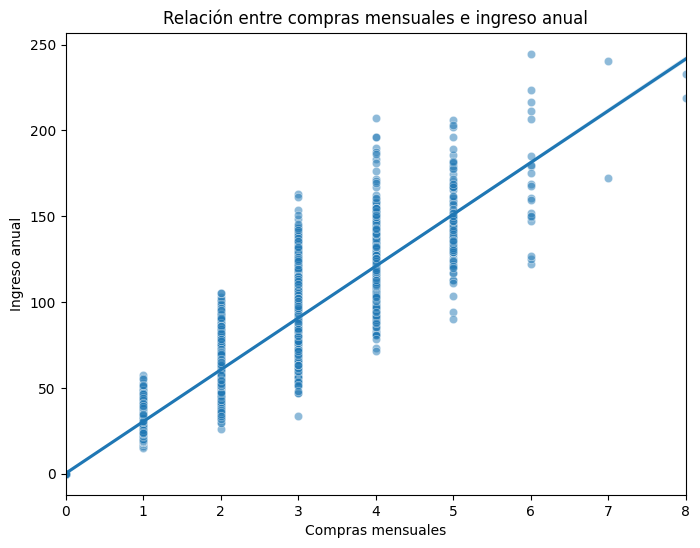

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual',
    scatter=False
)

plt.title('Relación entre compras mensuales e ingreso anual')
plt.xlabel('Compras mensuales')
plt.ylabel('Ingreso anual')
plt.show()

### Hallazgo 2

**Evidencia visual:**   
**Evidencia numérica:**: Pearson = 0.58 - Spearman = 0.56

**Interpretación**: Se observa una tendencia positiva entre el gasto publicitario y las visitas mensuales, aunque con una dispersión considerable. Entre 0 y 15 de gasto, la línea de tendencia presenta un cambio en su inclinación, mostrando que el comportamiento no es completamente uniforme. Para niveles similares de gasto, como alrededor de 30, las visitas presentan una variación amplia, lo que respalda que la relación sea moderada y no fuerte. También se observa algún posible valor atípico, como un registro cercano a gasto 70 con aproximadamente 17 visitas, que debería ser validado
El comportamiento observado sugiere que el gasto publicitario está relacionado con las visitas mensuales, pero existen otros factores que también podrían estar asociados con la cantidad de visitas.
A partir de este gráfico no podemos afirmar que un mayor gasto en publicidad cause un aumento en las visitas mensuales, se debería mantener y optimizar la inversión en publicidad dirigida, pero no asumir que aumentar el presupuesto generará automáticamente más visitas. Se recomienda identificar qué segmentos o campañas presentan una mejor relación entre inversión y visitas.

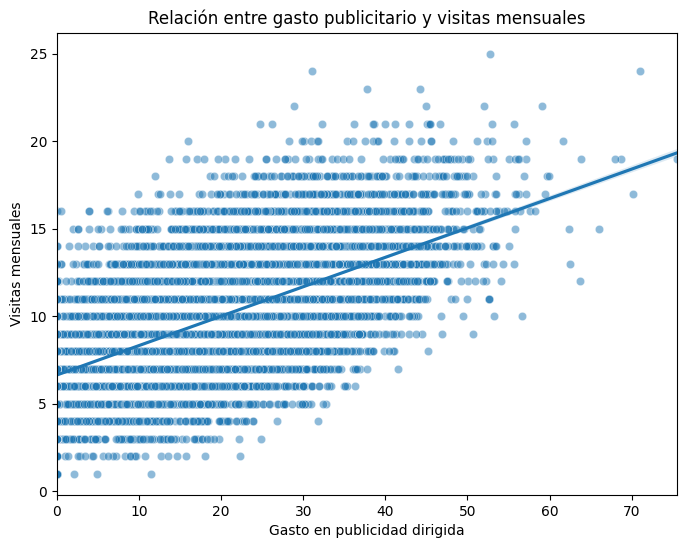

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='gasto_publicidad_dirigida',
    y='visitas_mes',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='gasto_publicidad_dirigida',
    y='visitas_mes',
    scatter=False
)

plt.title('Relación entre gasto publicitario y visitas mensuales')
plt.xlabel('Gasto en publicidad dirigida')
plt.ylabel('Visitas mensuales')
plt.show()

### Hallazgo 3

**Evidencia visual:**   
**Evidencia numérica:**: V de Cramér = 0.12

**Interpretación**: El gráfico muestra que el abandono es menor entre los clientes Premium: 4,4% frente a 16,8% en los clientes No Premium. Sin embargo, el V de Cramér de 0,12 indica que la asociación entre ambas variables es débil. Por lo tanto, podemos decir que existe una diferencia en el abandono entre los grupos, pero no podemos afirmar que pertenecer a Premium sea la causa de esa diferencia, esto representa una oportunidad para investigar qué beneficios o características del segmento Premium podrían estar relacionados con una mayor permanencia y evaluar su posible aplicación en estrategias de fidelización.

abandono         False  True 
miembro_premium              
False            10741   2170
True              1998     91
V de Cramér = 0.12


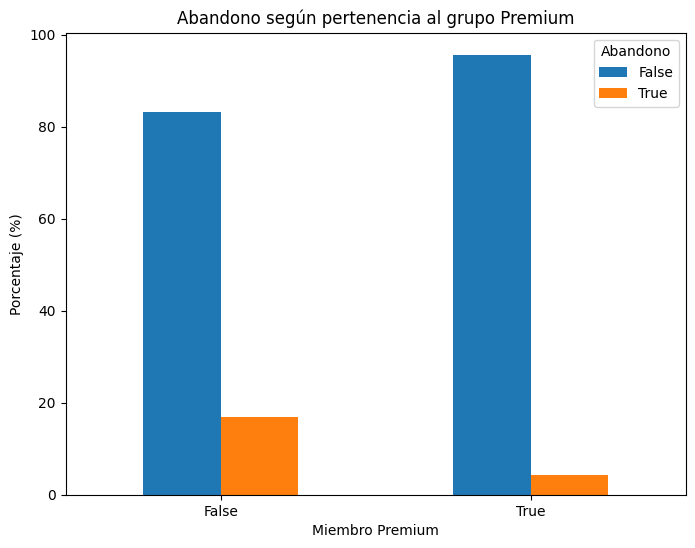

In [ ]:
tabla_premium_abandono = pd.crosstab(
    df['miembro_premium'],
    df['abandono']
)

print(tabla_premium_abandono)

v = v_de_cramer(
    df['miembro_premium'],
    df['abandono']
)

print(f'V de Cramér = {v:.2f}')

tabla_proporcion = pd.crosstab(
    df['miembro_premium'],
    df['abandono'],
    normalize='index'
) * 100

tabla_proporcion.plot(
    kind='bar',
    figsize=(8, 6)
)

plt.title('Abandono según pertenencia al grupo Premium')
plt.xlabel('Miembro Premium')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.legend(title='Abandono')
plt.show()

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
Los resultados obtenidos muestran asociaciones entre las variables, pero no permiten establecer relaciones de causa y efecto. La correlación más alta se encuentra entre compras e ingreso anual (r = 0,97), por lo que es importante validar cómo fueron construidas estas variables antes de interpretar esta relación. De igual manera, la relación entre gasto publicitario y visitas (r = 0,58) no demuestra que una mayor inversión genere más visitas, ya que pueden existir otros factores que expliquen el comportamiento observado. Finalmente, las correlaciones cercanas a cero entre satisfacción e ingreso o compras no descartan posibles relaciones no lineales

### **Próximos pasos**
-**Validar la construcción de las variables**:
Revisar el origen y la fórmula de ingreso_anual y compras_mes, especialmente porque presentan una correlación de 0,97, prácticamente perfecta. Se debería consultar el diccionario de datos y la documentación disponible para determinar si ambas variables fueron registradas de manera independiente o si una fue calculada a partir de la otra. Si una variable depende matemáticamente de la otra, la correlación podría reflejar principalmente la forma en que fueron construidos los datos y no un comportamiento real de los clientes.

**Probar segmentación adicional**:
Repetir el análisis de correlaciones dentro de diferentes segmentos, como clientes Premium y No Premium, nivel de actividad, tipo de dispositivo, edad y región. Esto permitirá comprobar si las relaciones observadas se mantienen de manera similar en todos los grupos o si están concentradas en un segmento específico. Por ejemplo, si la relación entre dos variables es similar en clientes móviles y de escritorio, el patrón tendría mayor consistencia; si cambia considerablemente entre ambos grupos, sería necesario investigar qué características del segmento podrían estar influyendo.

**Realizar una prueba A/B para publicidad**:
Debido a la correlación moderada entre gasto_publicidad_dirigida y visitas_mes (r = 0,58), se recomienda realizar una prueba A/B para evaluar si existe un efecto de la estrategia publicitaria sobre las visitas. El experimento permitirá comparar un grupo expuesto a la nueva estrategia con un grupo de control. Si se observa una diferencia significativa, se obtendría evidencia a favor de un posible efecto de la publicidad; si no se observa una diferencia significativa, no habría evidencia suficiente para afirmar que la nueva estrategia incrementa las visitas. De esta manera, el experimento permite tanto respaldar como cuestionar la relación observada en los datos históricos.